Converged at iteration 120
Test MSE: 109.39


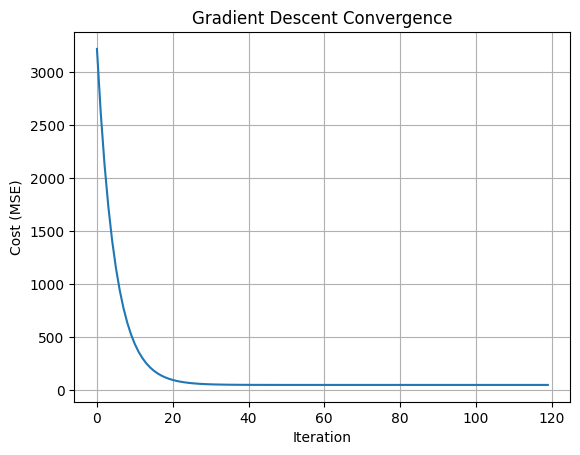

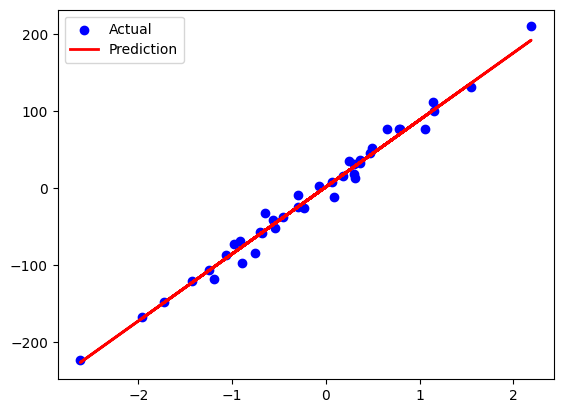

In [3]:
import numpy as np

class LinearRegression:
  """
    Linear Regression trained via Batch Gradient Descent.
    Built from scratch using only NumPy.
    """
  def __init__(self,learning_rate:float = 0.01,n_iterations: int = 1000,tolerance: float= 1e-6):
    self.lr = learning_rate
    self.n_iters = n_iterations
    self.tol = tolerance
    self.weights = None
    self.bias = None
    self.cost_history = [] #tracking

  def fit(self,X: np.ndarray, y: np.ndarray) -> None:
    """
        Trains the model using Batch Gradient Descent.
        X: 2D array (m samples, n features)
        y: 1D or 2D array (m targets)
        """
    # Ensure y is 1D for consistent broadcasting with weights
    y = y.ravel()
    m, n = X.shape
    self.weights = np.zeros(n)
    self.bias = 0.0

    for i in range(self.n_iters):
      #1. forward pass
      y_pred = X @ self.weights + self.bias

      #2. compute error
      error = y_pred - y

      #3. compute cost (MSE) and store for debugging
      cost = (1/(2*m)) * np.sum(error ** 2)
      self.cost_history.append(cost)

      #4. convergence check
      if i > 0 and abs(self.cost_history[-2] - cost) < self.tol:
        print(f"Converged at iteration {i+1}")
        break

      #5. compute gradients
      dw = (1/m) * (X.T @ error)
      db = (1/m) * np.sum(error)

      #6. update parameters
      self.weights -= self.lr * dw
      self.bias -= self.lr * db

  def predict(self,X: np.ndarray) -> np.ndarray:
    """generate predictions for new data"""
    return X @ self.weights + self.bias

# ######## Testing #################################

import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Generate synthetic data
X, y = make_regression(n_samples=200, n_features=1, noise=10, random_state=42)

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train model
model = LinearRegression(learning_rate=0.1, n_iterations=1000, tolerance=1e-8)
model.fit(X_train_scaled, y_train)

# 5. Predict & Evaluate
y_pred = model.predict(X_test_scaled)
mse = np.mean((y_test - y_pred) ** 2)
print(f"Test MSE: {mse:.2f}")

# 6. Visualize Cost Convergence
plt.plot(model.cost_history)
plt.title("Gradient Descent Convergence")
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE)")
plt.grid(True)
plt.show()

# 7. Visualize Regression Line
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, model.predict(X_test_scaled), color='red', linewidth=2, label='Prediction')
plt.legend()
plt.show()